# Telco Customer Churn: Exploratory Analysis

**How to use this notebook:** click a cell and press **Shift + Enter** to run it. Run the cells **from top to bottom, one at a time**, and read the output before moving on.

Data: `data/processed/customers_features.csv` (2,000 customers, 18 columns). This notebook only *reads* it and never changes it.

Colors used everywhere: **orange = churned**, **blue = stayed**.

## 1. Load the data

In [1]:
# Import the libraries we need
import pandas as pd                 # tables and calculations
import matplotlib.pyplot as plt     # drawing charts
import seaborn as sns               # nicer chart styles
from pathlib import Path            # file paths

ORANGE = '#E8743B'   # churned
BLUE = '#3B7EA1'     # stayed
sns.set_theme(style='whitegrid')

# Load the data (works whether the notebook runs from notebooks/ or the project root)
path = Path('../data/processed/customers_features.csv')
if not path.exists():
    path = Path('data/processed/customers_features.csv')
df = pd.read_csv(path)

print('Loaded from:', path)
print('Rows, columns:', df.shape)
df.head()

Loaded from: ..\data\processed\customers_features.csv
Rows, columns: (2000, 18)


,customerID,SeniorCitizen,Dependents,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag,senior_label,tenure_group,monthly_charges_band,has_internet,auto_pay
0,1273-MTETI,1,No,4,Fiber optic,No,No,Month-to-month,Electronic check,88.85,372.45,Yes,1,Yes,0-12 months,3-High ($70-$90),Yes,No
1,2483-XSSMZ,0,No,39,DSL,Yes,No,One year,Electronic check,47.85,1886.40,No,0,No,25-48 months,2-Medium ($35-$70),Yes,No
2,6994-KERXL,0,No,4,DSL,No,No,Month-to-month,Electronic check,55.90,238.50,No,0,No,0-12 months,2-Medium ($35-$70),Yes,No
3,2192-CKRLV,0,No,72,DSL,Yes,No,Two year,Electronic check,49.20,3580.95,No,0,No,49-72 months,2-Medium ($35-$70),Yes,No
4,5982-PSMKW,0,Yes,23,DSL,Yes,Yes,Two year,Credit card (automatic),91.10,2198.30,No,0,No,13-24 months,4-Very high (over $90),Yes,Yes


In [2]:
import sys
print(sys.executable)

c:\Users\HP\OneDrive\Documents\Telco Customer Churn\venv\Scripts\python.exe


## 2. Quick health check
The same checks as before: missing values, duplicates, unique IDs and blank-space values.

In [3]:
print('Missing values:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('customerID unique:', df.customerID.is_unique)

# Blank-space values hide from isna(), so check the text columns separately
text_cols = df.select_dtypes(exclude='number')
print('Blank-space values:', text_cols.apply(lambda s: s.astype(str).str.strip().eq('')).sum().sum())

Missing values: 0
Duplicate rows: 0
customerID unique: True
Blank-space values: 0


## 3. Q1: What is the overall churn rate?
`churn_flag` is 1 for churned and 0 for stayed, so its **average** is the churn rate.

In [4]:
overall = df.churn_flag.mean() * 100
print(f'Overall churn rate: {overall:.1f}%')
df.churn_flag.value_counts().rename({0: 'Stayed', 1: 'Churned'})

Overall churn rate: 26.6%


churn_flag
Stayed     1469
Churned     531
Name: count, dtype: int64

## 4. Two helper functions (defined once, used many times)
- `churn_table` is the **pandas** part. It groups customers and calculates the churn rate for each group.
- `plot_churn` is the **drawing** part. It turns that table into a bar chart.

In [5]:
def churn_table(data, column, sort_by_rate=False):
    """Group customers by `column`; count them, count churners, and get the churn rate (%)."""
    table = data.groupby(column).agg(
        customers=('churn_flag', 'size'),    # how many customers in each group
        churned=('churn_flag', 'sum'),       # how many of them churned
        churn_rate=('churn_flag', 'mean'),   # churned / customers
    )
    table['churn_rate'] = (table['churn_rate'] * 100).round(1)
    if sort_by_rate:
        table = table.sort_values('churn_rate', ascending=False)
    return table


def plot_churn(table, title, baseline=None):
    """Draw a horizontal bar chart of churn rate, with the number of customers on each bar."""
    fig, ax = plt.subplots(figsize=(8, 0.9 * len(table) + 1.5))
    ax.barh(table.index.astype(str), table['churn_rate'], color=ORANGE)
    ax.invert_yaxis()   # first row at the top
    for i, (rate, n) in enumerate(zip(table['churn_rate'], table['customers'])):
        ax.text(rate + 0.8, i, f'{rate:.1f}%  (n={n})', va='center', zorder=3,
                bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
    if baseline is not None:
        ax.axvline(baseline, color='grey', linestyle='--', label=f'Overall churn {baseline:.1f}%')
        ax.legend(loc='lower right')
    ax.set_xlim(0, max(table['churn_rate'].max() * 1.35, 10))
    ax.set_xlabel('Churn rate (%)')
    ax.set_ylabel('')
    ax.set_title(title, loc='left', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Q2: Churn by tenure (how long they have been a customer)

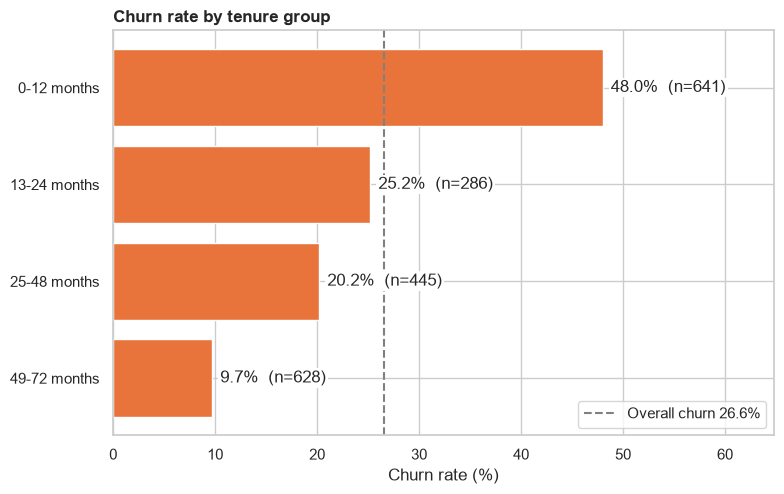

,customers,churned,churn_rate
tenure_group,,,
0-12 months,641,308,48.0
13-24 months,286,72,25.2
25-48 months,445,90,20.2
49-72 months,628,61,9.7


In [6]:
t = churn_table(df, 'tenure_group')
plot_churn(t, 'Churn rate by tenure group', overall)
t

## 6. Q3: Churn by contract type

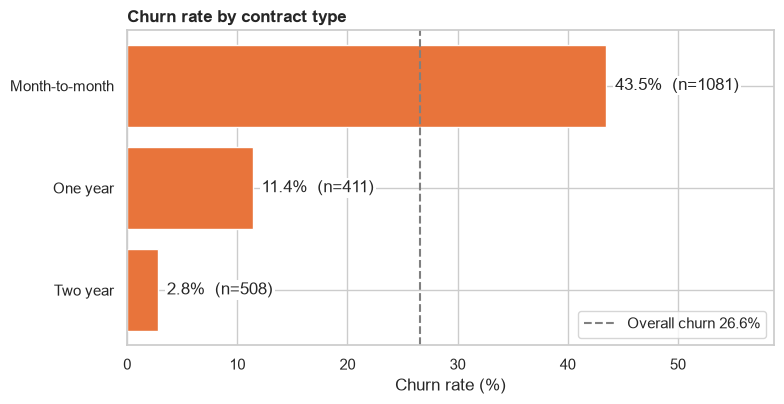

,customers,churned,churn_rate
Contract,,,
Month-to-month,1081,470,43.5
One year,411,47,11.4
Two year,508,14,2.8


In [7]:
t = churn_table(df, 'Contract', sort_by_rate=True)
plot_churn(t, 'Churn rate by contract type', overall)
t

## 7. Q4: Churn by internet service

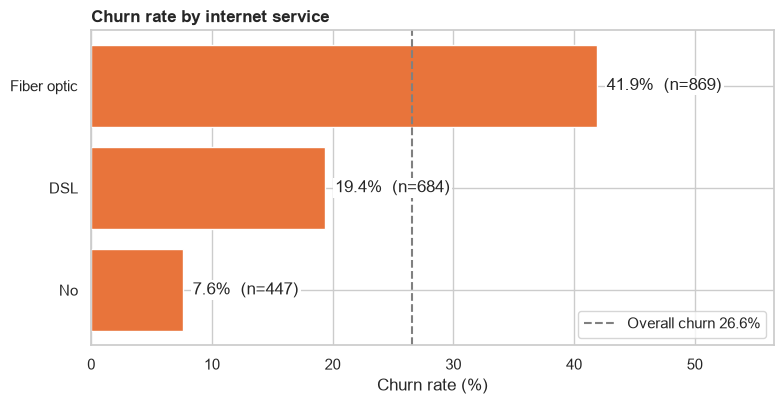

,customers,churned,churn_rate
InternetService,,,
Fiber optic,869,364,41.9
DSL,684,133,19.4
No,447,34,7.6


In [8]:
t = churn_table(df, 'InternetService', sort_by_rate=True)
plot_churn(t, 'Churn rate by internet service', overall)
t

## 8. Q5: Churn by payment method

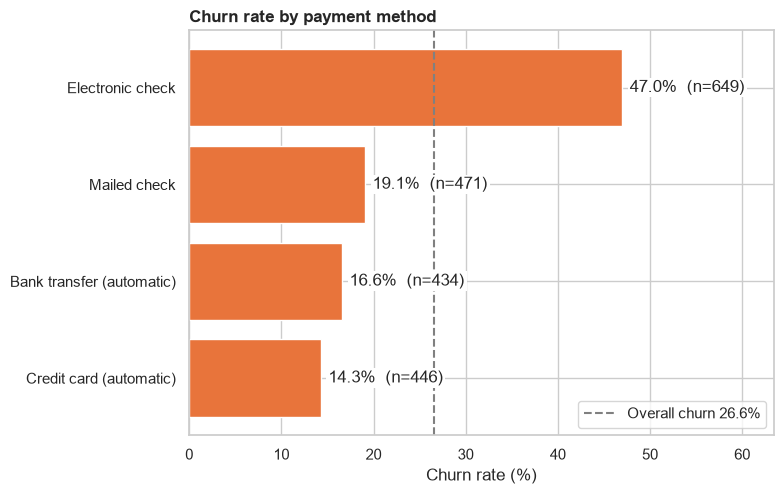

,customers,churned,churn_rate
PaymentMethod,,,
Electronic check,649,305,47.0
Mailed check,471,90,19.1
Bank transfer (automatic),434,72,16.6
Credit card (automatic),446,64,14.3


In [9]:
t = churn_table(df, 'PaymentMethod', sort_by_rate=True)
plot_churn(t, 'Churn rate by payment method', overall)
t

## 9. Q6: Do TechSupport and OnlineSecurity matter?
We look at **internet customers only**. Customers with no internet have no such services, and they churn for a different reason, so mixing them in would blur the comparison.

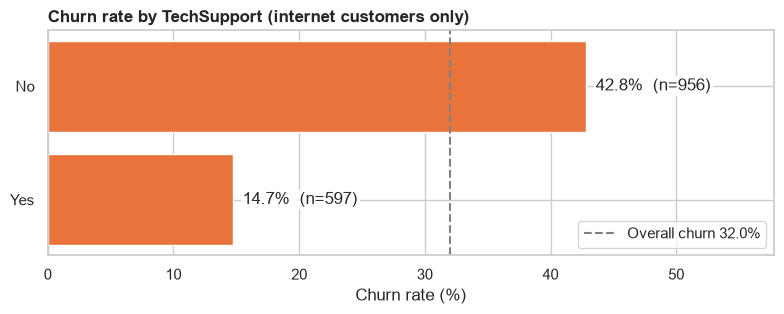

,customers,churned,churn_rate
TechSupport,,,
No,956,409,42.8
Yes,597,88,14.7


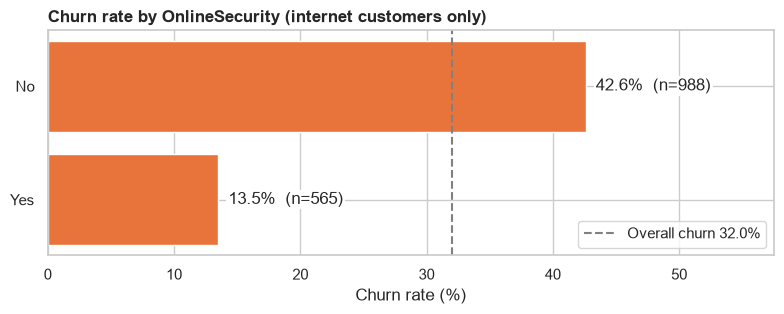

,customers,churned,churn_rate
OnlineSecurity,,,
No,988,421,42.6
Yes,565,76,13.5


In [10]:
internet = df[df.has_internet == 'Yes']
overall_internet = internet.churn_flag.mean() * 100

for col in ['TechSupport', 'OnlineSecurity']:
    t = churn_table(internet, col, sort_by_rate=True)
    plot_churn(t, f'Churn rate by {col} (internet customers only)', overall_internet)
    display(t)

## 10. Q7: Do senior citizens churn more?

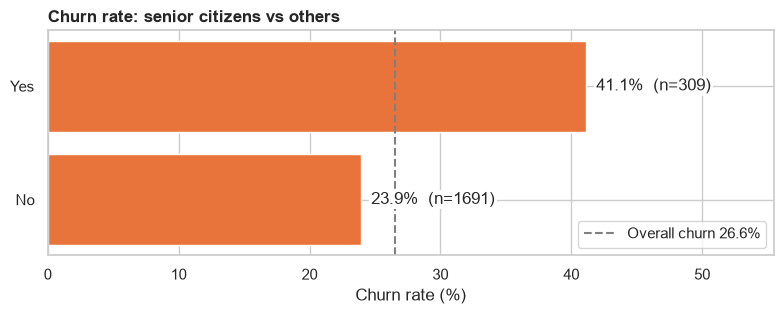

,customers,churned,churn_rate
senior_label,,,
Yes,309,127,41.1
No,1691,404,23.9


In [11]:
t = churn_table(df, 'senior_label', sort_by_rate=True)
plot_churn(t, 'Churn rate: senior citizens vs others', overall)
t

## 11. Q8: Does contract type matter *after* accounting for tenure?
Month-to-month customers are often newer customers, so the two effects can be tangled together. This heatmap separates them. A `*` marks cells with **fewer than 30 customers**: treat those percentages with caution.

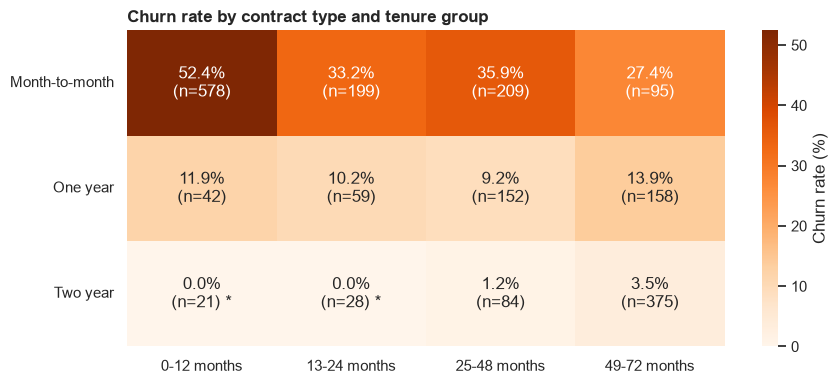

In [12]:
rate = df.pivot_table(index='Contract', columns='tenure_group', values='churn_flag', aggfunc='mean') * 100
count = df.pivot_table(index='Contract', columns='tenure_group', values='churn_flag', aggfunc='size')

# Text inside each cell: churn rate and number of customers
labels = rate.round(1).astype(str) + '%\n(n=' + count.astype(str) + ')'
labels = labels.where(count >= 30, labels + ' *')

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(rate, annot=labels, fmt='', cmap='Oranges', cbar_kws={'label': 'Churn rate (%)'}, ax=ax)
ax.set_title('Churn rate by contract type and tenure group', loc='left', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)   # keep the row labels horizontal
plt.tight_layout()
plt.show()

## 12. Q9: Do churned customers pay more per month?
First for **all** customers, then for **internet customers only**. Compare the two.

Median monthly charge, ALL customers:
Churn
No     64.15
Yes    79.15
Name: MonthlyCharges, dtype: float64

Median monthly charge, INTERNET customers only:
Churn
No     78.975
Yes    79.750
Name: MonthlyCharges, dtype: float64


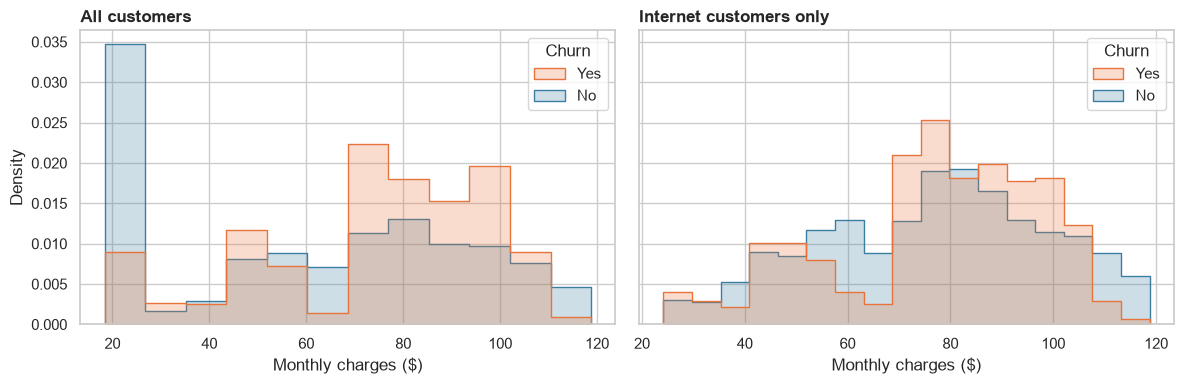

In [13]:
print('Median monthly charge, ALL customers:')
print(df.groupby('Churn').MonthlyCharges.median())
print()
print('Median monthly charge, INTERNET customers only:')
print(internet.groupby('Churn').MonthlyCharges.median())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, data, name in zip(axes, [df, internet], ['All customers', 'Internet customers only']):
    sns.histplot(data=data, x='MonthlyCharges', hue='Churn', stat='density', common_norm=False,
                 element='step', palette={'Yes': ORANGE, 'No': BLUE}, ax=ax)
    ax.set_title(name, loc='left', fontweight='bold')
    ax.set_xlabel('Monthly charges ($)')
plt.tight_layout()
plt.show()

**Read this carefully:** in the all-customers view, churned customers seem to pay more. But look at the internet-only medians. The gap is much smaller. Customers with *no internet* pay little and rarely churn, which pulls the "stayed" group's price down. That is called a **confounder**: a third factor that distorts a comparison. Price alone is not the story.

## 13. Save the summary tables
These CSVs will feed the AI report step later. They go into `outputs/notebook_tables/`.

In [15]:
out = path.parent.parent.parent / 'outputs' / 'notebook_tables'
out.mkdir(parents=True, exist_ok=True)

for col in ['tenure_group', 'Contract', 'InternetService', 'PaymentMethod',
            'senior_label', 'monthly_charges_band', 'auto_pay']:
    churn_table(df, col).to_csv(out / f'churn_by_{col}.csv')

print('Saved tables to:', out)

Saved tables to: ..\outputs\notebook_tables


#Insights:

**1. Churn is concentrated in the first year.**
Customers in their first 12 months churn at about 48.0%, versus 9.7% for customers with 4+ years (overall churn is 26.6%). Retention effort should focus on onboarding and the first year, when customers are most likely to leave.

**2. Contract type is the strongest single pattern.**
Month-to-month customers churn at about 43.5%, versus about 2.8% on two-year contracts. Offering incentives to move month-to-month customers onto longer contracts is a promising retention idea.

**3. The contract effect is not just a tenure effect.**
Even among customers with 49-72 months of tenure, month-to-month customers churn at about 27.4% versus 3.5% on two-year contracts. So contract type matters beyond how long someone has been a customer. (Caution: the two-year x 0-12 months and 13-24 months cells have only 21 and 28 customers, so those percentages are unreliable.)

**4. Fiber optic and electronic check customers stand out.**
Fiber optic customers churn at about 41.9%, roughly 2.2 times the DSL rate. Electronic check payers churn at about 47.0%, versus about 14.3% for automatic credit card payers. These groups overlap with month-to-month contracts, so the factors are tangled together. They are worth investigating (service quality, billing friction), not proven causes.

**5. Support and security services go with lower churn.**
Among internet customers only, those without tech support or online security churn at about 43%, versus 13-15% for those who have them. Customers who use these services may be more engaged, so this is a link, not proof that the services prevent churn. A trial or bundle offer would be a low-risk way to test it.

**6. Higher price does not explain churn on its own.**
Across all customers, churned customers appear to pay more (median about $79 versus $64). Among internet customers only, the medians are nearly the same (about $80 versus $79). The gap comes from customers with no internet, who pay little and rarely churn. This is a confounder: comparing price alone would mislead.

**7. Senior citizens churn much more.**
Senior citizens churn at about 41.1%, versus 23.9% for other customers. Seniors are a smaller group (about 15% of customers), but the gap is large enough to justify a targeted retention approach.

## Limitations
- This is a 2,000-row random sample of an IBM sample dataset, not live company data.
- All findings are associations, not proof of cause.
- Several factors overlap (contract, payment method, internet type), and only contract and tenure were separated.
- Some heatmap cells have fewer than 30 customers.
- The data is a single snapshot, so it cannot show how churn changes over time.

**Top recommendation**
Focus retention on new, month-to-month customers, especially fiber optic and electronic check customers. Test incentives for longer contracts and bundled support or security services, then measure the effect.
